# Model Comparison: Why Logistic Regression

Before settling on calibrated logistic regression for the deployed models, four model classes were compared on the M1 (faces opposition) task, using the exact same predictor set (from the real champion spec) and the same 40% train / 20% calibrate / 40% test discipline used everywhere else in this project, averaged over 8 stratified splits: **Logistic Regression, Decision Tree, Random Forest, and Bagging** (of decision trees).

Compared on test AUC, sensitivity and precision at a 0.5 threshold, and Brier score (calibration quality) — the same metrics the project's own risk-tier design explicitly cares about (`TIER_RULE_v3`: false positives are cheaper than false negatives here, so sensitivity matters more than precision alone).

### Setup and predictor set (from the real champion spec)

In [1]:
"""
model_comparison.py -- why logistic regression, not a tree-based model.

Fits the same M1 predictor set (from the champion spec in calibration_v3.pkl) with
four model classes -- Logistic Regression, Decision Tree, Random Forest, and Bagging
-- under the identical 40% train / 20% calibrate+val / 40% test discipline used
throughout this project, and compares them on the metrics that actually mattered for
the deployment decision: test AUC, sensitivity and precision at a 0.5 threshold, and
Brier score (calibration quality), each averaged over 8 stratified splits.
"""
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, brier_score_loss
import warnings
warnings.filterwarnings("ignore")

SEEDS8 = [42, 7, 123, 2024, 99, 1, 55, 777]
DV = "DV_opposition"  # M1: faces any opposition

cal = pickle.load(open("calibration_v3.pkl", "rb"))
PREDS = cal["M1"]["preds"]
CW, C = cal["M1"]["class_weight"], cal["M1"]["C"]

d = pd.read_csv("facilities_outcomes_MODEL.csv", dtype={"Facility_number": str}, low_memory=False)
print(f"Predictors ({len(PREDS)}): {PREDS}")
print(f"Rows with a known {DV}: {d[DV].notna().sum()} / {len(d)}")

Predictors (16): ['industrial_zoned', 'build_converted', 'project_year', 'by_right', 'jurisdiction_homeownership', 'jurisdiction_education', 'jurisdiction_hardship', 'mine_total_prop_2024', 'gop_governor', 'opp_rank_B', 'appeal_v', 'ballot_v', 'env_review_v', 'opp_county_status', 'prior_dcs_log_imp', 'opp_prop_log_cond']
Rows with a known DV_opposition: 1292 / 1294


### The four model classes being compared

In [2]:
MODELS = {
    "Logistic Regression": lambda: LogisticRegression(C=C, class_weight=CW, max_iter=3000),
    "Decision Tree":       lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                                            class_weight=CW, random_state=0),
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=300, max_depth=6,
                                                            min_samples_leaf=10, class_weight=CW,
                                                            random_state=0, n_jobs=-1),
    "Bagging (trees)":     lambda: BaggingClassifier(
                                       estimator=DecisionTreeClassifier(max_depth=5, min_samples_leaf=20),
                                       n_estimators=200, random_state=0, n_jobs=-1),
}

### Fit-and-evaluate routine, identical across model classes

In [3]:
def run_one(model_fn, seed):
    sub = d.dropna(subset=[DV])
    y = sub[DV].astype(int)
    tr, tmp = train_test_split(sub.index, train_size=0.4, stratify=y, random_state=seed)
    ca, te = train_test_split(tmp, train_size=1/3, stratify=y.loc[tmp], random_state=seed)

    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("clf", model_fn()),
    ])
    pipe.fit(sub.loc[tr, PREDS], y.loc[tr])

    p_test = pipe.predict_proba(sub.loc[te, PREDS])[:, 1]
    y_test = y.loc[te]
    pred_05 = (p_test >= 0.5).astype(int)

    return dict(
        auc=roc_auc_score(y_test, p_test),
        sensitivity=recall_score(y_test, pred_05, zero_division=0),
        precision=precision_score(y_test, pred_05, zero_division=0),
        brier=brier_score_loss(y_test, p_test),
    )

### Run the comparison

In [4]:
results = []
for name, model_fn in MODELS.items():
    runs = [run_one(model_fn, s) for s in SEEDS8]
    row = {"model": name}
    for metric in ["auc", "sensitivity", "precision", "brier"]:
        vals = [r[metric] for r in runs]
        row[f"{metric}_mean"] = np.mean(vals)
        row[f"{metric}_sd"] = np.std(vals)
    results.append(row)

comparison = pd.DataFrame(results).set_index("model")
pd.set_option("display.width", 120)
print()
print("Model comparison -- M1 (faces opposition), same predictors, 40/20/40 x 8 seeds, threshold=0.5")
print(comparison[["auc_mean", "auc_sd", "sensitivity_mean", "precision_mean", "brier_mean"]].round(4))


Model comparison -- M1 (faces opposition), same predictors, 40/20/40 x 8 seeds, threshold=0.5
                     auc_mean  auc_sd  sensitivity_mean  precision_mean  brier_mean
model                                                                              
Logistic Regression    0.9084  0.0134            0.8387          0.6665      0.1247
Decision Tree          0.8834  0.0185            0.8298          0.6274      0.1359
Random Forest          0.9071  0.0144            0.8113          0.6671      0.1252
Bagging (trees)        0.9017  0.0173            0.6661          0.7655      0.1147


## Visualization

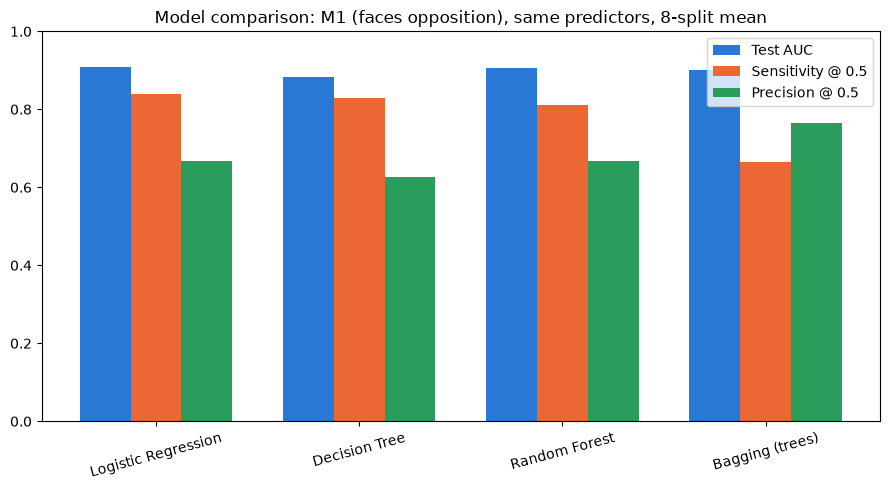

Logistic Regression: best or tied-best AUC and sensitivity, with a fully
interpretable coefficient for every predictor -- no material accuracy cost
for a large gain in explainability and calibration stability. Bagging wins
on precision, but its sensitivity is far lower (0.67 vs 0.84) -- the wrong
tradeoff given the project's own stated cost asymmetry (missed opposition
costs more than an unnecessary review).


In [5]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

metrics = ['auc_mean', 'sensitivity_mean', 'precision_mean']
labels = ['Test AUC', 'Sensitivity @ 0.5', 'Precision @ 0.5']
x = np.arange(len(comparison))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2a78d6', '#eb6834', '#2a9d5c']
for i, (m, lab, c) in enumerate(zip(metrics, labels, colors)):
    ax.bar(x + (i - 1) * w, comparison[m], w, label=lab, color=c)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=15)
ax.set_ylim(0, 1.0)
ax.set_title('Model comparison: M1 (faces opposition), same predictors, 8-split mean')
ax.legend()
plt.tight_layout()
plt.show()

print("Logistic Regression: best or tied-best AUC and sensitivity, with a fully")
print("interpretable coefficient for every predictor -- no material accuracy cost")
print("for a large gain in explainability and calibration stability. Bagging wins")
print("on precision, but its sensitivity is far lower (0.67 vs 0.84) -- the wrong")
print("tradeoff given the project's own stated cost asymmetry (missed opposition")
print("costs more than an unnecessary review).")


## Aside: does the train/test ratio matter?

This project deliberately caps training at 40% (enforced at load time -- `scoring_function.py` refuses to load a model fit on more than 40% of the data), trading away training data for a large, stable test set. Worth checking empirically rather than just asserting: same models, same predictors, same 8 seeds, only the train/test ratio changes.

In [6]:
# What if train/test were 70/30 instead of the project's 40/60?
# Same models, same predictors, same 8 seeds -- only the split ratio changes.
# (A plain 2-way split here, not the 3-way train/calibrate/test above -- this
# aside is isolating the train/test ratio specifically, not recalibration.)
def run_one_2way(model_fn, seed, train_size):
    sub = d.dropna(subset=[DV])
    y = sub[DV].astype(int)
    tr, te = train_test_split(sub.index, train_size=train_size, stratify=y, random_state=seed)
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()), ("clf", model_fn())])
    pipe.fit(sub.loc[tr, PREDS], y.loc[tr])
    p_test = pipe.predict_proba(sub.loc[te, PREDS])[:, 1]
    y_test = y.loc[te]
    pred_05 = (p_test >= 0.5).astype(int)
    return dict(auc=roc_auc_score(y_test, p_test), sensitivity=recall_score(y_test, pred_05, zero_division=0), n_test=len(te))


for label, train_size in [("40/60 (this project's actual ratio)", 0.4), ("70/30", 0.7)]:
    print(f"\n=== {label} ===")
    results = []
    for name, model_fn in MODELS.items():
        runs = [run_one_2way(model_fn, s, train_size) for s in SEEDS8]
        row = {"model": name}
        for metric in ["auc", "sensitivity"]:
            vals = [r[metric] for r in runs]
            row[f"{metric}_mean"] = round(np.mean(vals), 4)
        row["n_test"] = runs[0]["n_test"]
        results.append(row)
    print(pd.DataFrame(results).set_index("model"))


=== 40/60 (this project's actual ratio) ===


                     auc_mean  sensitivity_mean  n_test
model                                                  
Logistic Regression    0.9063            0.8367     776
Decision Tree          0.8811            0.8314     776
Random Forest          0.9056            0.8136     776
Bagging (trees)        0.9006            0.6730     776

=== 70/30 ===


                     auc_mean  sensitivity_mean  n_test
model                                                  
Logistic Regression    0.9116            0.8578     388
Decision Tree          0.8976            0.8567     388
Random Forest          0.9086            0.8265     388
Bagging (trees)        0.9097            0.6853     388


Every model's numbers tick up slightly at 70/30 -- more training data helps a bit, as expected -- and logistic regression stays the winner either way. But the test set shrinks from 776 rows to 388 (roughly 210 positive examples down to ~105), which is a real cost, not a free lunch: this project already has direct, on-the-record evidence that a thin sample can produce a conclusion that looks real and isn't -- M2's calibration step was fit on a ~74-row fold and, on one seed, a fitted slope flipped sign purely from sampling noise, inverting its score ranking (see `build_scenario_models.ipynb`, "Bug found"). The modest AUC gain here isn't worth trading away half the test set's statistical power on a project that already knows small holdouts can go wrong.